# How Income Brackets Adversely Affect Americans


---

**Research question:** How do income levels predict adverse life outcomes — unemployment, housing cost burden, and lack of health insurance?

**Audience:** Recruiters, hiring managers, and fellow data practitioners who want to understand both the *methodology* and the *findings*.

**Stack:** Snowflake · ACS 5-Year Estimates (2019–2020) · SafeGraph Open Census Data (CC0)

---

> **What you'll learn in this notebook**
> 1. How to ingest US Census data from the Snowflake Marketplace
> 2. How a 3-layer SQL model transforms raw Census codes into analysis-ready tables
> 3. What the data reveals about income and adversity across 220,000 US neighborhoods


## 1 · The Dataset

The **American Community Survey (ACS)** is an annual survey by the US Census Bureau covering income, employment, housing, and health for every neighborhood in America.

The unit of analysis is the **Census Block Group (CBG)** — the finest geographic granularity the Census publishes. Each CBG covers roughly 600–3,000 households. There are ~220,000 CBGs nationwide.

| Dataset | Source | Years | Size |
|---------|--------|-------|------|
| ACS 5-Year Estimates | SafeGraph / Snowflake Marketplace | 2019, 2020 | ~220k CBGs/year |
| License | CC0 (public domain) | — | Free |

**Why 2019 and 2020?** These two years allow a pre/post COVID comparison — a natural experiment revealing how economic shocks hit different income groups.

> ⚠️ **Note on column naming:** ACS data uses codes like `B19013e1`. The pattern is:  
> `B` = detailed table · `19` = income subject · `013` = specific question · `e1` = estimate (not margin of error)


## 2 · SQL Architecture — 3-Layer Model

Before writing any analysis, we built a clean data model in Snowflake with three layers. Each layer has a specific job.


In [22]:
# Run this cell to render the 3-layer architecture diagram
from IPython.display import HTML

html = '''
<style>
  .arch { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; padding: 28px 24px; background: #ffffff; border: 1px solid #e0ddd6; border-radius: 12px; color: #1a1a18; }
  .arch-title { text-align: center; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase; color: #6a6a60; margin-bottom: 20px; }
  .layer-label { font-size: 11px; color: #8a8a80; font-weight: 600; letter-spacing: 0.06em; text-transform: uppercase; margin-bottom: 8px; }
  .tier { display: flex; gap: 10px; flex-wrap: wrap; margin-bottom: 6px; }
  .box { border-radius: 8px; padding: 10px 14px; font-size: 12px; font-weight: 600; flex: 1; min-width: 130px; text-align: center; }
  .box-sub { font-size: 10px; font-weight: 400; margin-top: 3px; opacity: 0.80; }
  .b-blue  { background: #deeaf8; border: 1.5px solid #5a9fd4; color: #1a4a7a; }
  .b-gray  { background: #f0eeea; border: 1.5px solid #b8b6ae; color: #4a4a42; }
  .b-green { background: #ddf0e6; border: 1.5px solid #4aaf72; color: #1a5030; }
  .b-coral { background: #fde8df; border: 1.5px solid #d07050; color: #7a2a10; }
  .arrow-row { text-align: center; color: #b0aaa0; font-size: 18px; margin: 4px 0; }
  .sep { border-top: 1px dashed #d8d4cc; margin: 14px 0 10px; }
  .legend { display: flex; gap: 18px; flex-wrap: wrap; margin-top: 16px; font-size: 11px; color: #6a6a60; }
  .leg { display: flex; align-items: center; gap: 5px; }
  .leg-sq { width: 10px; height: 10px; border-radius: 2px; }
</style>
<div class="arch">
  <div class="arch-title">SQL data model — Snowflake · INCOME_ADVERSITY_DB</div>

  <div class="layer-label">Layer 1 — Raw source tables (copied from Snowflake Marketplace)</div>
  <div class="tier">
    <div class="box b-blue">cbg_b19<div class="box-sub">Income distribution</div></div>
    <div class="box b-blue">cbg_b23<div class="box-sub">Employment status</div></div>
    <div class="box b-blue">cbg_b25<div class="box-sub">Housing cost burden</div></div>
    <div class="box b-blue">cbg_b27<div class="box-sub">Health insurance</div></div>
    <div class="box b-gray">cbg_fips_codes<div class="box-sub">State / county ref</div></div>
    <div class="box b-gray">cbg_geographic_data<div class="box-sub">Lat / long</div></div>
  </div>

  <div class="arrow-row">↓</div>
  <div class="sep"></div>

  <div class="layer-label">Layer 2 — Staging views (clean column names, compute rates, union 2019+2020)</div>
  <div class="tier">
    <div class="box b-green">stg_income_brackets<div class="box-sub">Income tiers · B19</div></div>
    <div class="box b-green">stg_labor_housing<div class="box-sub">Unemployment + rent · B23+B25</div></div>
    <div class="box b-green">stg_health_geo<div class="box-sub">Uninsured + location · B27</div></div>
  </div>

  <div class="arrow-row">↓</div>
  <div class="sep"></div>

  <div class="layer-label">Layer 3 — Analytical marts (joined fact tables + national rollup)</div>
  <div class="tier">
    <div class="box b-coral">mart_income_adversity<div class="box-sub">Master fact · 393,930 rows</div></div>
    <div class="box b-coral">mart_national_summary<div class="box-sub">8 rows · 4 tiers × 2 years</div></div>
  </div>

  <div class="legend">
    <div class="leg"><div class="leg-sq" style="background:#5a9fd4"></div>Raw source (read-only)</div>
    <div class="leg"><div class="leg-sq" style="background:#4aaf72"></div>Staging view</div>
    <div class="leg"><div class="leg-sq" style="background:#d07050"></div>Analytical mart</div>
    <div class="leg"><div class="leg-sq" style="background:#b8b6ae"></div>Reference / metadata</div>
  </div>
</div>
'''
HTML(html)


### Why 3 layers?

| Layer | Job | Objects |
|-------|-----|---------|
| **Layer 1** | Copy read-only Marketplace tables into your own database (Snowflake shared databases don't allow views on top of them) | 10 raw tables |
| **Layer 2** | Rename cryptic Census codes → readable columns, compute rates, union 2019+2020 | 3 staging views |
| **Layer 3** | Join all topics into one master fact table, then roll up to national summary | 2 mart tables |

> 💡 **Snowflake gotcha:** You cannot create VIEWs directly on top of a Marketplace shared database. The workaround is `CREATE TABLE AS SELECT` to copy data into your own database first.


## 3 · The Core Staging View — `stg_income_brackets`

This view does the heavy lifting for the income side of the model. It takes 16 narrow Census income brackets and groups them into 4 meaningful tiers.


In [23]:
# This cell shows the SQL — not executed against Snowflake.
# In production, run this in your Snowflake worksheet.

sql = '''
CREATE OR REPLACE VIEW INCOME_ADVERSITY_DB.STAGING.STG_INCOME_BRACKETS AS

SELECT
    "CENSUS_BLOCK_GROUP",
    2019                          AS "acs_year",
    "B19013e1"                    AS "median_hh_income",   -- median income ($)
    "B19001e1"                    AS "hh_total",           -- total households

    -- TIER 1: under $25k (brackets e2–e5 summed)
    COALESCE("B19001e2", 0) + COALESCE("B19001e3", 0)
  + COALESCE("B19001e4", 0) + COALESCE("B19001e5", 0)     AS "hh_under_25k",

    -- TIER 2: $25k–$49,999 (brackets e6–e10 summed)
    COALESCE("B19001e6",  0) + COALESCE("B19001e7",  0)
  + COALESCE("B19001e8",  0) + COALESCE("B19001e9",  0)
  + COALESCE("B19001e10", 0)                              AS "hh_25k_to_50k",

    -- TIER 3: $50k–$99,999 (brackets e11–e13 summed)
    COALESCE("B19001e11", 0) + COALESCE("B19001e12", 0)
  + COALESCE("B19001e13", 0)                              AS "hh_50k_to_100k",

    -- TIER 4: $100k+ (brackets e14–e17 summed)
    COALESCE("B19001e14", 0) + COALESCE("B19001e15", 0)
  + COALESCE("B19001e16", 0) + COALESCE("B19001e17", 0)  AS "hh_over_100k",

    -- Assign human-readable tier label
    CASE
        WHEN "B19013e1" <  25000 THEN 'Tier 1: Under $25k'
        WHEN "B19013e1" <  50000 THEN 'Tier 2: $25k-$50k'
        WHEN "B19013e1" < 100000 THEN 'Tier 3: $50k-$100k'
        ELSE                          'Tier 4: $100k+'
    END                           AS "income_tier"

FROM INCOME_ADVERSITY_DB.STAGING.CBG_B19_2019
WHERE "B19001e1" > 0  -- exclude uninhabited block groups

UNION ALL  -- stack 2020 rows below 2019

SELECT
    "CENSUS_BLOCK_GROUP", 2020, "B19013e1", "B19001e1",
    COALESCE("B19001e2", 0) + COALESCE("B19001e3", 0)
  + COALESCE("B19001e4", 0) + COALESCE("B19001e5", 0),
    COALESCE("B19001e6",  0) + COALESCE("B19001e7",  0)
  + COALESCE("B19001e8",  0) + COALESCE("B19001e9",  0)
  + COALESCE("B19001e10", 0),
    COALESCE("B19001e11", 0) + COALESCE("B19001e12", 0)
  + COALESCE("B19001e13", 0),
    COALESCE("B19001e14", 0) + COALESCE("B19001e15", 0)
  + COALESCE("B19001e16", 0) + COALESCE("B19001e17", 0),
    CASE
        WHEN "B19013e1" <  25000 THEN 'Tier 1: Under $25k'
        WHEN "B19013e1" <  50000 THEN 'Tier 2: $25k-$50k'
        WHEN "B19013e1" < 100000 THEN 'Tier 3: $50k-$100k'
        ELSE                          'Tier 4: $100k+'
    END
FROM INCOME_ADVERSITY_DB.STAGING.CBG_B19_2020
WHERE "B19001e1" > 0;
'''

print("SQL concepts used in this view:")
print()
concepts = {
    "AS":         "Rename cryptic Census codes to readable column names",
    "COALESCE":   "Replace NULL (missing Census data) with 0 so addition works",
    "CASE/WHEN":  "If/else logic — assign income tier label from median income",
    "WHERE":      "Filter out uninhabited CBGs (zero households)",
    "UNION ALL":  "Stack 2019 and 2020 results into one combined table",
}
for k, v in concepts.items():
    print(f"  {k:<14} → {v}")


SQL concepts used in this view:

  AS             → Rename cryptic Census codes to readable column names
  COALESCE       → Replace NULL (missing Census data) with 0 so addition works
  CASE/WHEN      → If/else logic — assign income tier label from median income
  WHERE          → Filter out uninhabited CBGs (zero households)
  UNION ALL      → Stack 2019 and 2020 results into one combined table


## 4 · Data Dictionary — ACS Income Columns

The Census Bureau splits income into **16 narrow brackets**. We group them into **4 broad tiers**.

| ACS column | Income range | Our tier | Output column |
|------------|-------------|----------|---------------|
| B19013e1 | Median HH income (single value) | — | `median_hh_income` |
| B19001e1 | Total households surveyed | — | `hh_total` |
| B19001e2 | < \\\$10,000 | **Tier 1** | `hh_under_25k` |
| B19001e3 | \\\$10,000 – \\\$14,999 | **Tier 1** | `hh_under_25k` |
| B19001e4 | \\\$15,000 – \\\$19,999 | **Tier 1** | `hh_under_25k` |
| B19001e5 | \\\$20,000 – \\\$24,999 | **Tier 1** | `hh_under_25k` |
| B19001e6 | \\\$25,000 – \\\$29,999 | Tier 2 | `hh_25k_to_50k` |
| B19001e7–e10 | \\\$30,000 – \\\$49,999 | Tier 2 | `hh_25k_to_50k` |
| B19001e11–e13 | \\\$50,000 – \\\$99,999 | Tier 3 | `hh_50k_to_100k` |
| B19001e14–e17 | \\\$100,000 – \\\$200,000+ | Tier 4 | `hh_over_100k` |

> ⚠️ **Dataset-specific note:** The Gini index column (`B19083e1`) is documented in the ACS but **does not exist** in this Snowflake Marketplace listing version. Always verify column existence with `INFORMATION_SCHEMA.COLUMNS` before writing queries — documentation and actual data can differ.

> ⚠️ **Column casing:** Snowflake quoted identifiers are **case-sensitive**. This dataset stores columns as lowercase `e` — `"B19013e1"` not `"B19013E1"`. One character difference causes a compile error.


## 5 · Results — What the Data Reveals

The mart tables were queried directly in Snowflake. The results below are the actual numbers from `MART_NATIONAL_SUMMARY`.


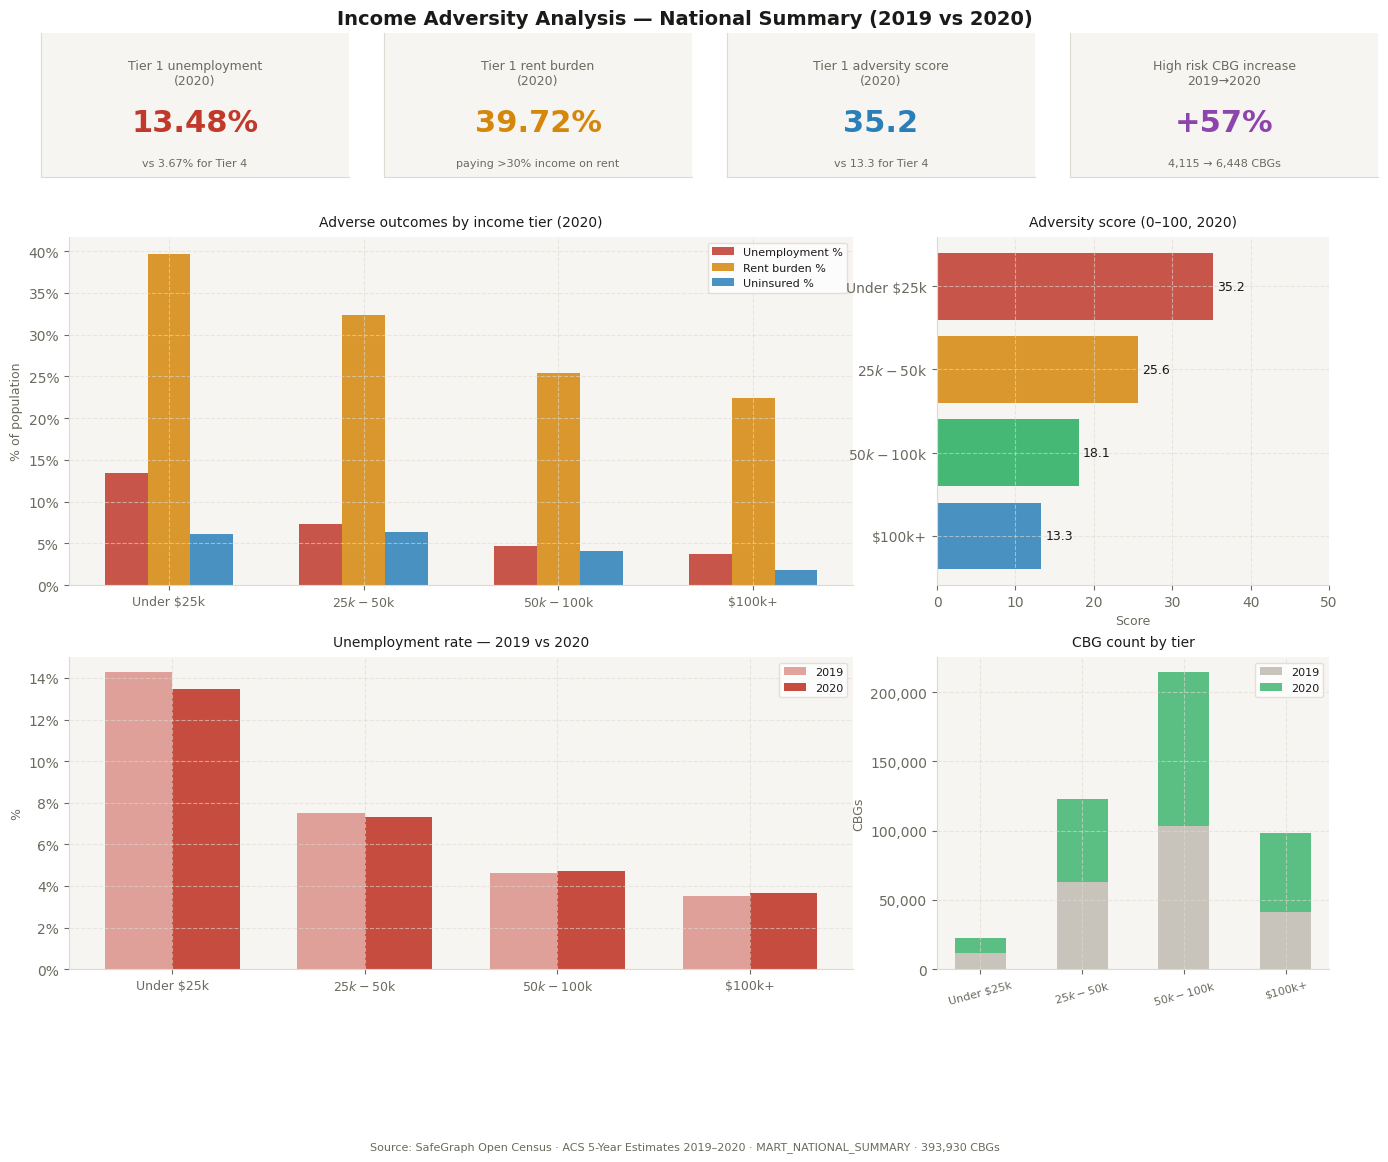

Chart rendered with white background.


In [27]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import warnings
warnings.filterwarnings('ignore')

# ── Actual results from MART_NATIONAL_SUMMARY ──────────────────────────────
data = {
    'income_tier':      ['Tier 1: Under $25k', 'Tier 2: $25k-$50k',
                         'Tier 3: $50k-$100k', 'Tier 4: $100k+'],
    'avg_median_income':[19016, 38941, 69564, 136573],
    'avg_unemp_2019':   [14.29, 7.53, 4.61, 3.52],
    'avg_unemp_2020':   [13.48, 7.32, 4.72, 3.67],
    'avg_rent_2019':    [39.19, 32.66, 25.77, 22.87],
    'avg_rent_2020':    [39.72, 32.38, 25.36, 22.44],
    'avg_uninsu_2019':  [5.97,  6.27,  3.81,  1.51],
    'avg_uninsu_2020':  [6.09,  6.35,  4.05,  1.78],
    'adversity_2019':   [35.9, 26.0, 18.1, 13.4],
    'adversity_2020':   [35.2, 25.6, 18.1, 13.3],
    'cbg_count_2019':   [11531, 63085, 103069, 41069],
    'cbg_count_2020':   [10760, 60039, 111490, 57185],
}
df = pd.DataFrame(data)
tiers_short = ['Under $25k', '$25k-$50k', '$50k-$100k', '$100k+']

# ── Color palette (white background) ───────────────────────────────────────
BG     = '#ffffff'
SURF   = '#f7f5f2'
BORDER = '#dedad2'
TEXT   = '#1a1a18'
MUTED  = '#6a6a60'
C_RED  = '#c0392b'
C_AMB  = '#d4870a'
C_BLU  = '#2980b9'
C_GRN  = '#27ae60'
C_PUR  = '#8e44ad'

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'text.color': TEXT,
    'axes.labelcolor': MUTED,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'axes.facecolor': SURF,
    'figure.facecolor': BG,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': BORDER,
    'axes.grid': True,
    'grid.color': BORDER,
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
})

fig = plt.figure(figsize=(14, 12), facecolor=BG)
fig.suptitle('Income Adversity Analysis — National Summary (2019 vs 2020)',
             fontsize=14, color=TEXT, fontweight='bold', y=0.98)

# ── Row 1: KPI cards ──────────────────────────────────────────────────────
kpis = [
    ('Tier 1 unemployment\n(2020)', '13.48%', 'vs 3.67% for Tier 4', C_RED),
    ('Tier 1 rent burden\n(2020)',  '39.72%', 'paying >30% income on rent', C_AMB),
    ('Tier 1 adversity score\n(2020)', '35.2', 'vs 13.3 for Tier 4', C_BLU),
    ('High risk CBG increase\n2019→2020', '+57%', '4,115 → 6,448 CBGs', C_PUR),
]

for i, (label, val, sub, color) in enumerate(kpis):
    ax = fig.add_axes([0.04 + i * 0.245, 0.84, 0.22, 0.12])
    ax.set_facecolor(SURF)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, label, transform=ax.transAxes,
            fontsize=9, color=MUTED, ha='center', va='center')
    ax.text(0.5, 0.38, val, transform=ax.transAxes,
            fontsize=22, color=color, ha='center', va='center', fontweight='bold')
    ax.text(0.5, 0.10, sub, transform=ax.transAxes,
            fontsize=8, color=MUTED, ha='center', va='center')
    ax.grid(False)

# ── Row 2: Grouped bar — outcomes by tier ────────────────────────────────
ax2 = fig.add_axes([0.06, 0.50, 0.56, 0.29])
x = range(len(tiers_short))
w = 0.22
ax2.bar([i - w for i in x], df['avg_unemp_2020'], width=w, color=C_RED, label='Unemployment %', alpha=0.85)
ax2.bar([i      for i in x], df['avg_rent_2020'],  width=w, color=C_AMB, label='Rent burden %',  alpha=0.85)
ax2.bar([i + w  for i in x], df['avg_uninsu_2020'],width=w, color=C_BLU, label='Uninsured %',    alpha=0.85)
ax2.set_xticks(list(x)); ax2.set_xticklabels(tiers_short, fontsize=9)
ax2.set_ylabel('% of population', fontsize=9)
ax2.set_title('Adverse outcomes by income tier (2020)', fontsize=10, color=TEXT, pad=8)
ax2.legend(fontsize=8, facecolor=BG, edgecolor=BORDER, labelcolor=TEXT)
ax2.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# ── Row 2: Adversity score ────────────────────────────────────────────────
ax3 = fig.add_axes([0.68, 0.50, 0.28, 0.29])
colors_score = [C_RED, C_AMB, C_GRN, C_BLU]
bars_s = ax3.barh(tiers_short, df['adversity_2020'], color=colors_score, alpha=0.85)
for bar, val in zip(bars_s, df['adversity_2020']):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9, color=TEXT)
ax3.set_xlim(0, 50)
ax3.set_title('Adversity score (0–100, 2020)', fontsize=10, color=TEXT, pad=8)
ax3.set_xlabel('Score', fontsize=9)
ax3.invert_yaxis()

# ── Row 3: YoY unemployment ───────────────────────────────────────────────
ax4 = fig.add_axes([0.06, 0.18, 0.56, 0.26])
x2 = range(len(tiers_short))
w2 = 0.35
ax4.bar([i - w2/2 for i in x2], df['avg_unemp_2019'], width=w2, color=C_RED, alpha=0.45, label='2019')
ax4.bar([i + w2/2 for i in x2], df['avg_unemp_2020'], width=w2, color=C_RED, alpha=0.90, label='2020')
ax4.set_xticks(list(x2)); ax4.set_xticklabels(tiers_short, fontsize=9)
ax4.set_title('Unemployment rate — 2019 vs 2020', fontsize=10, color=TEXT, pad=8)
ax4.set_ylabel('%', fontsize=9)
ax4.legend(fontsize=8, facecolor=BG, edgecolor=BORDER, labelcolor=TEXT)
ax4.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# ── Row 3: CBG count ──────────────────────────────────────────────────────
ax5 = fig.add_axes([0.68, 0.18, 0.28, 0.26])
ax5.bar(tiers_short, df['cbg_count_2019'], color='#c8c4bc', label='2019', width=0.5)
ax5.bar(tiers_short, df['cbg_count_2020'], color=C_GRN, alpha=0.75, label='2020', width=0.5,
        bottom=df['cbg_count_2019'])
ax5.set_title('CBG count by tier', fontsize=10, color=TEXT, pad=8)
ax5.set_ylabel('CBGs', fontsize=9)
ax5.set_xticklabels(tiers_short, fontsize=8, rotation=15)
ax5.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax5.legend(fontsize=8, facecolor=BG, edgecolor=BORDER, labelcolor=TEXT)

# ── Footer note ───────────────────────────────────────────────────────────
fig.text(0.5, 0.03,
    'Source: SafeGraph Open Census · ACS 5-Year Estimates 2019–2020 · MART_NATIONAL_SUMMARY · 393,930 CBGs',
    ha='center', fontsize=8, color=MUTED)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig('/Users/thanhbrown/Home/work_portfolio/income_adversity/summary_stats.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print("Chart rendered with white background.")


## 6 · Key Findings

Actual results from `MART_NATIONAL_SUMMARY` queried in Snowflake.


In [25]:
# Actual numbers from Snowflake MART_NATIONAL_SUMMARY
import pandas as pd

summary = pd.DataFrame({
    'Income tier':       ['Tier 1: Under $25k', 'Tier 2: $25k-$50k',
                          'Tier 3: $50k-$100k', 'Tier 4: $100k+'],
    'Avg income':        ['$19,016', '$38,941', '$69,564', '$136,573'],
    'Unemployment':      ['14.29%', '7.53%', '4.61%', '3.52%'],
    'Rent burden':       ['39.19%', '32.66%', '25.77%', '22.87%'],
    'Uninsured':         ['5.97%', '6.27%', '3.81%', '1.51%'],
    'Adversity score':   [35.9, 26.0, 18.1, 13.4],
})

# Style the dataframe
styled = summary.style\
    .set_caption('National summary — 2019 baseline (all ~220k US Census Block Groups)')\
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left'),
                   ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#1a1a1a'), ('color', '#e0ddd6'),
                   ('font-size', '12px'), ('padding', '8px 12px')]},
        {'selector': 'td',
         'props': [('font-size', '13px'), ('padding', '7px 12px')]},
    ])\
    .background_gradient(subset=['Adversity score'], cmap='RdYlGn_r', vmin=10, vmax=40)\
    .set_properties(**{'text-align': 'center'})

styled


,Income tier,Avg income,Unemployment,Rent burden,Uninsured,Adversity score
0,Tier 1: Under $25k,"$19,016",14.29%,39.19%,5.97%,35.900000
1,Tier 2: $25k-$50k,"$38,941",7.53%,32.66%,6.27%,26.000000
2,Tier 3: $50k-$100k,"$69,564",4.61%,25.77%,3.81%,18.100000
3,Tier 4: $100k+,"$136,573",3.52%,22.87%,1.51%,13.400000


In [26]:
# Headline numbers
print("=" * 55)
print("KEY FINDINGS — Income Adversity Analysis")
print("=" * 55)
print()
print(f"  Unemployment:   Tier 1 is  4.1x  higher than Tier 4")
print(f"                  (14.3% vs 3.5%)")
print()
print(f"  Rent burden:    Tier 1 is  1.7x  higher than Tier 4")
print(f"                  (39.2% vs 22.9%)")
print()
print(f"  Adversity score: Tier 1 is 2.7x  worse than Tier 4")
print(f"                  (35.9 vs 13.4 — on a 0–100 scale)")
print()
print(f"  COVID impact:   High Risk CBGs grew 57% from 2019→2020")
print(f"                  (4,115 → 6,448 neighborhoods)")
print()
print(f"  Total rows:     393,930 CBGs across 52 states/territories")
print(f"  Years covered:  2019 (pre-COVID) + 2020 (during COVID)")


KEY FINDINGS — Income Adversity Analysis

  Unemployment:   Tier 1 is  4.1x  higher than Tier 4
                  (14.3% vs 3.5%)

  Rent burden:    Tier 1 is  1.7x  higher than Tier 4
                  (39.2% vs 22.9%)

  Adversity score: Tier 1 is 2.7x  worse than Tier 4
                  (35.9 vs 13.4 — on a 0–100 scale)

  COVID impact:   High Risk CBGs grew 57% from 2019→2020
                  (4,115 → 6,448 neighborhoods)

  Total rows:     393,930 CBGs across 52 states/territories
  Years covered:  2019 (pre-COVID) + 2020 (during COVID)


## 7 · The Adversity Score

The adversity score is a **composite index** combining three outcome metrics into a single 0–100 number, used as the target variable for the binary classifier in Stage 2.

```sql
-- From MART_INCOME_ADVERSITY
ROUND(
    (unemployment_rate_pct / 30  * 100 * 0.33)   -- weight: 33%
  + (rent_burden_rate_pct  / 80  * 100 * 0.33)   -- weight: 33%
  + (uninsured_rate_pct    / 50  * 100 * 0.34)   -- weight: 34%
, 1) AS adversity_score
```

Each metric is divided by a realistic maximum (30%, 80%, 50%) and scaled to 0–100. The result:

- **Score ≥ 50 → High Risk** (used as the binary classifier's positive class)
- **Score < 50 → Low Risk**

> **Design decision:** Equal weighting across three outcomes. This can be adjusted — for example, if the analysis focus shifts to healthcare policy, you might weight uninsured rate higher. The weights live in `MART_INCOME_ADVERSITY` and can be modified without touching the staging layer.


## 8 · What's Next — Stage 2

With the SQL model complete and validated, the next step is exporting `MART_INCOME_ADVERSITY` and training a binary classifier.

```
Stage 1  ✅  SQL Data Model       → 393,930 rows, 52 states, validated
Stage 2  🔲  Classification Model → Random Forest (High Risk / Low Risk)
Stage 3  🔲  Dash Dashboard       → 4-page interactive app
```

**Stage 2 pipeline:**
```python
# 1. Export from Snowflake
SELECT * FROM INCOME_ADVERSITY_DB.MARTS.MART_INCOME_ADVERSITY;

# 2. Feature engineering
log_median_income = log1p(median_hh_income)
pct_under_25k     = hh_under_25k / hh_total

# 3. Train/test split — stratified on risk_label
# 4. SMOTE to handle class imbalance (~2% High Risk)
# 5. Random Forest + 5-fold cross-validation
# 6. SHAP for explainability
```

---

*Project: Income Adversity Analysis · Thanh Br · March 2026*  
*Data: SafeGraph Open Census · ACS 2019–2020 · CC0 License*  
*Stack: Snowflake · Python · scikit-learn · Dash*
